Amplitude = 2.509102 ± 0.053745
Center = 1.069093 ± 0.048672
Sigma = 1.967842 ± 0.048672
Reduced chi-square = 0.033248


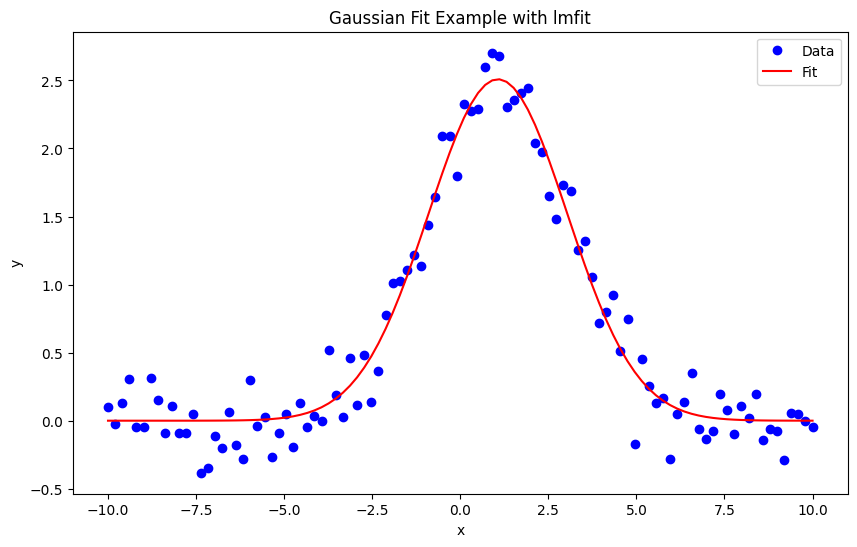

In [7]:
import numpy as np
from lmfit import minimize, Parameters
import matplotlib.pyplot as plt

# Generate some sample data with noise
x = np.linspace(-10, 10, 100)
true_amplitude = 2.5
true_center = 1.0
true_sigma = 2.0

# Create noisy data
y_true = true_amplitude * np.exp(-(x - true_center)**2 / (2 * true_sigma**2))
np.random.seed(42)
y_noise = 0.2 * np.random.normal(size=x.size)
y_data = y_true + y_noise

# Define the Gaussian model function
def gaussian(params, x, y=None):
    amplitude = params['amplitude']
    center = params['center'] 
    sigma = params['sigma']
    model = amplitude * np.exp(-(x - center)**2 / (2 * sigma**2))
    if y is None:
        return model
    return model - y

# Create parameters with initial guesses
params = Parameters()
params.add('amplitude', value=1.0, min=0)
params.add('center', value=0.0)
params.add('sigma', value=1.0, min=0)

# Perform the fit
result = minimize(gaussian, 
                 params, 
                 args=(x, y_data),
                 method='leastsq',
                 max_nfev=10000,
                 ftol=1e-11,
                 xtol=1e-11)

# Print selective results
print(f"Amplitude = {result.params['amplitude'].value:.6f} ± {result.params['amplitude'].stderr:.6f}")
print(f"Center = {result.params['center'].value:.6f} ± {result.params['center'].stderr:.6f}")
print(f"Sigma = {result.params['sigma'].value:.6f} ± {result.params['sigma'].stderr:.6f}")
print(f"Reduced chi-square = {result.redchi:.6f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(x, y_data, 'bo', label='Data')
plt.plot(x, gaussian(result.params, x), 'r-', label='Fit')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gaussian Fit Example with lmfit')
plt.show()

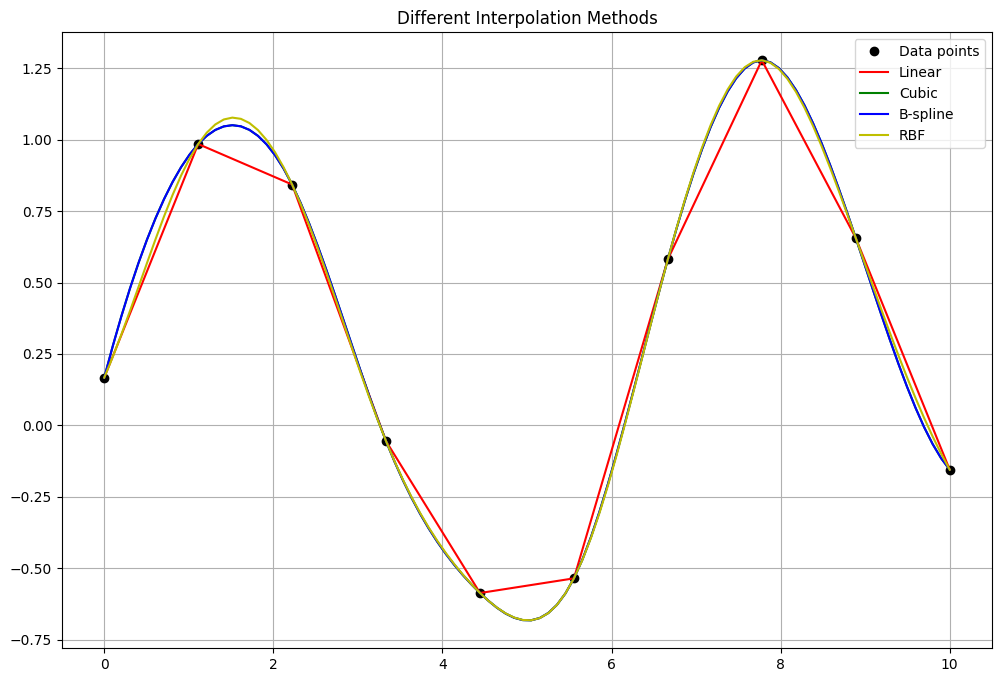

In [2]:
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt

# Generate some sample data
x = np.linspace(0, 10, 10)
y = np.sin(x) + np.random.random(10) * 0.4

# Create a finer x scale for plotting interpolation
x_new = np.linspace(0, 10, 100)


# 1. Linear interpolation (simplest)
f_linear = interpolate.interp1d(x, y)
y_linear = f_linear(x_new)

# 2. Cubic spline interpolation (smoother)
f_cubic = interpolate.interp1d(x, y, kind='cubic')
y_cubic = f_cubic(x_new)

# 3. B-spline representation
tck = interpolate.splrep(x, y, s=0)
y_bspline = interpolate.splev(x_new, tck, der=0)

# 4. Radial Basis Function (RBF) interpolation
rbf = interpolate.Rbf(x, y, function='multiquadric')
y_rbf = rbf(x_new)

# Plot all interpolations
plt.figure(figsize=(12, 8))
plt.plot(x, y, 'ko', label='Data points')
plt.plot(x_new, y_linear, 'r-', label='Linear')
plt.plot(x_new, y_cubic, 'g-', label='Cubic')
plt.plot(x_new, y_bspline, 'b-', label='B-spline')
plt.plot(x_new, y_rbf, 'y-', label='RBF')
plt.legend()
plt.title('Different Interpolation Methods')
plt.grid(True)
plt.show()

Output file tmi_results.csv already exists. Reading results from it.


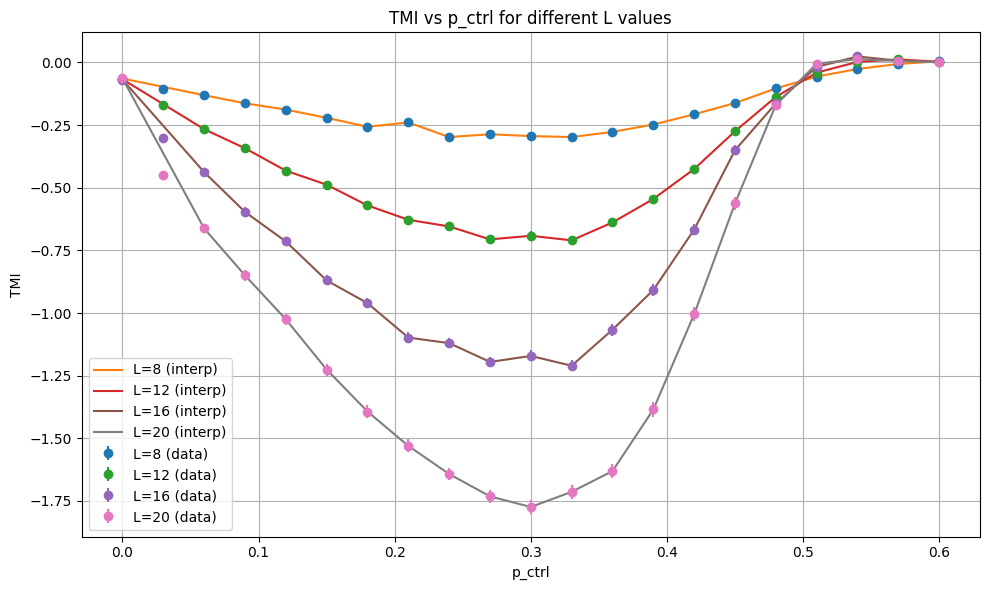

In [4]:
from data_collapse import read_tmi_results, linear_interpolation
L_values = [8, 12, 16, 20]
data = read_tmi_results(L_values, n=0, threshold=1e-10)
# Get p_proj values from first L
L_first = L_values[0]
p_proj_values = sorted([float(key.replace('pproj', '')) for key in data[L_first].keys()])

# Get p_ctrl values
p_ctrl_values = np.linspace(0, 0.6, len(data[L_first][f'pproj{p_proj_values[0]:.3f}']['tmi_mean']))
# Create a plot for each p_proj value
p_proj = p_proj_values[0]
p_all = [p_ctrl_values] * len(L_values)
L_all = L_values
y_all = [np.array(data[L][f'pproj{p_proj:.3f}']['tmi_mean']) for L in L_values]
sigma_y_all = [np.array(data[L][f'pproj{p_proj:.3f}']['tmi_sem']) for L in L_values]

def sort_x(p_arr, L_arr, pc, nu):
    x = lambda p, L, pc, nu: (p - pc) * L ** (1 / nu)
    x_vals = x(p_arr, L_arr, pc, nu)
    sort_idx = np.argsort(x_vals)
    return x_vals[sort_idx]

def linear_interpolation_all(x_sorted, y_sorted, sigma_y_sorted):
    "This linear interpolation function returns an array of interpolated y and sigma"
    y_prime = []
    sigma_prime = []
    for x_target in x_sorted:
        y_prime_target, sigma_prime_target = linear_interpolation(x_sorted, y_sorted, sigma_y_sorted, x_target)
        y_prime.append(y_prime_target)
        sigma_prime.append(sigma_prime_target)
    return np.array(y_prime), np.array(sigma_prime)

# Plot original data and interpolated curves
plt.figure(figsize=(10, 6))

# Plot data and interpolation for each L value
for i, L in enumerate(L_values):
    # Get data for this L
    x = p_ctrl_values
    y = np.array(y_all[i])
    sigma_y = np.array(sigma_y_all[i])
    
    # Sort by x values
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]
    sigma_y_sorted = sigma_y[sort_idx]
    
    # Get interpolated values
    y_interp, sigma_interp = linear_interpolation_all(x_sorted, y_sorted, sigma_y_sorted)
    
    # Plot original data with error bars
    plt.errorbar(x_sorted, y_sorted, yerr=sigma_y_sorted, fmt='o', label=f'L={L} (data)')
    
    # Plot interpolated curve  
    plt.plot(x_sorted, y_interp, '-', label=f'L={L} (interp)')
    
plt.title('TMI vs p_ctrl for different L values')
plt.xlabel('p_ctrl')
plt.ylabel('TMI')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
